# 03 Baseline Models
## 1. Load processed data
## 2. Basic cleaning
## 3. Feature construction
## 4. TF-IDF + Logistic Regression
## 5. LightGBM baseline
## 6. Evaluation
## 7. Result tables and figures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..")
TRAIN_PATH = BASE_DIR / "data" / "processed" / "train_merged_20k.parquet"
VALID_PATH = BASE_DIR / "data" / "processed" / "valid_merged_10k.parquet"

train_df = pd.read_parquet(TRAIN_PATH)
valid_df = pd.read_parquet(VALID_PATH)

print("train shape:", train_df.shape)
print("valid shape:", valid_df.shape)

train_df.head()

train shape: (737762, 15)
valid shape: (375609, 15)


,impression_id,user_id,time,history,history_len,candidate_news_id,label,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,9,N55689,1,N55689,sports,football_nfl,"Charles Rogers, former Michigan State football...","Charles Rogers, the former Michigan State foot...",https://assets.msn.com/labs/mind/BBWAPO6.html,"[{""Label"": ""Charles Rogers (American football)...","[{""Label"": ""2003 NFL Draft"", ""Type"": ""U"", ""Wik..."
1,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,9,N35729,0,N35729,news,newsus,Porsche launches into second story of New Jers...,The Porsche went airborne off a median in Toms...,https://assets.msn.com/labs/mind/BBWyjM9.html,"[{""Label"": ""Porsche"", ""Type"": ""O"", ""WikidataId...","[{""Label"": ""Porsche"", ""Type"": ""O"", ""WikidataId..."
2,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,82,N20678,0,N20678,sports,more_sports,Bode Miller delivered his twin boys after midw...,Bode Miller added yet another impressive title...,https://assets.msn.com/labs/mind/BBWERWB.html,"[{""Label"": ""Bode Miller"", ""Type"": ""P"", ""Wikida...","[{""Label"": ""Bode Miller"", ""Type"": ""P"", ""Wikida..."
3,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,82,N39317,0,N39317,news,newspolitics,"Senior Trump official embellished résumé, had ...",State Dept. official Mina Chang claimed to be ...,https://assets.msn.com/labs/mind/BBWEmIj.html,"[{""Label"": ""Donald Trump"", ""Type"": ""P"", ""Wikid...","[{""Label"": ""Harvard Business School"", ""Type"": ..."
4,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,82,N58114,0,N58114,autos,autosnews,2020 Ford Explorer launch hardly went accordin...,None,https://assets.msn.com/labs/mind/BBWEGnz.html,"[{""Label"": ""Ford Explorer"", ""Type"": ""V"", ""Wiki...",[]


In [2]:
required_cols = [
    "candidate_news_id",
    "label",
    "title",
    "abstract",
    "category",
    "subcategory",
    "history_len"
]

for col in required_cols:
    print(col, "->", col in train_df.columns)

candidate_news_id -> True
label -> True
title -> True
abstract -> True
category -> True
subcategory -> True
history_len -> True


In [3]:
print("train CTR:", train_df["label"].mean())
print("valid CTR:", valid_df["label"].mean())

train CTR: 0.040519842442413675
valid CTR: 0.0407791080618409


In [4]:
plt.rcParams["figure.dpi"] = 140
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

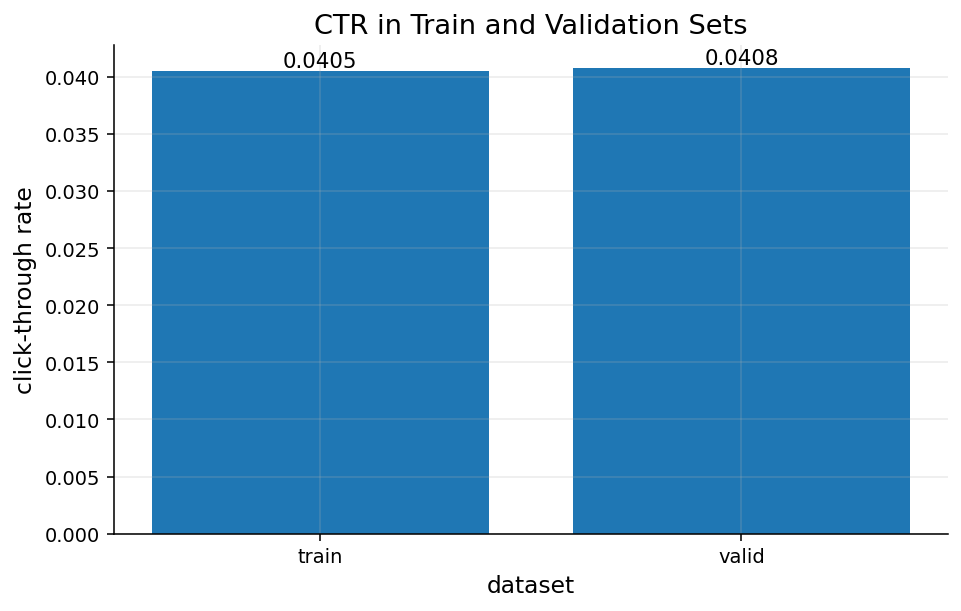

In [5]:
ctr_df = pd.DataFrame({
    "dataset": ["train", "valid"],
    "ctr": [train_df["label"].mean(), valid_df["label"].mean()]
})

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(ctr_df["dataset"], ctr_df["ctr"])
ax.set_title("CTR in Train and Validation Sets")
ax.set_xlabel("dataset")
ax.set_ylabel("click-through rate")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.4f}",
            ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [6]:
text_cols = ["title", "abstract", "category", "subcategory"]

for col in text_cols:
    train_df[col] = train_df[col].fillna("")
    valid_df[col] = valid_df[col].fillna("")

train_df[text_cols].isnull().sum()

title          0
abstract       0
category       0
subcategory    0
dtype: int64

In [7]:
train_df["title_text"] = train_df["title"].astype(str)
valid_df["title_text"] = valid_df["title"].astype(str)

In [8]:
train_df["title_abstract_text"] = (
    train_df["title"].astype(str) + " " + train_df["abstract"].astype(str)
)

valid_df["title_abstract_text"] = (
    valid_df["title"].astype(str) + " " + valid_df["abstract"].astype(str)
)

In [9]:
train_df["title_len"] = train_df["title"].astype(str).apply(len)
train_df["abstract_len"] = train_df["abstract"].astype(str).apply(len)

valid_df["title_len"] = valid_df["title"].astype(str).apply(len)
valid_df["abstract_len"] = valid_df["abstract"].astype(str).apply(len)

做 category 和 subcategory 的编码

先把训练集和验证集合在一起取类别全集，再编码，避免验证集出现新类别报错。

In [10]:
all_category = pd.concat([train_df["category"], valid_df["category"]]).astype(str)
all_subcategory = pd.concat([train_df["subcategory"], valid_df["subcategory"]]).astype(str)

category_map = {v: i for i, v in enumerate(sorted(all_category.unique()))}
subcategory_map = {v: i for i, v in enumerate(sorted(all_subcategory.unique()))}

train_df["category_id"] = train_df["category"].map(category_map)
valid_df["category_id"] = valid_df["category"].map(category_map)

train_df["subcategory_id"] = train_df["subcategory"].map(subcategory_map)
valid_df["subcategory_id"] = valid_df["subcategory"].map(subcategory_map)

构造LightGBM用的特征表

In [11]:
feature_cols = [
    "history_len",
    "title_len",
    "abstract_len",
    "category_id",
    "subcategory_id"
]

X_train_tab = train_df[feature_cols].copy()
X_valid_tab = valid_df[feature_cols].copy()

y_train = train_df["label"].copy()
y_valid = valid_df["label"].copy()

print(X_train_tab.shape, y_train.shape)
print(X_valid_tab.shape, y_valid.shape)

(737762, 5) (737762,)
(375609, 5) (375609,)


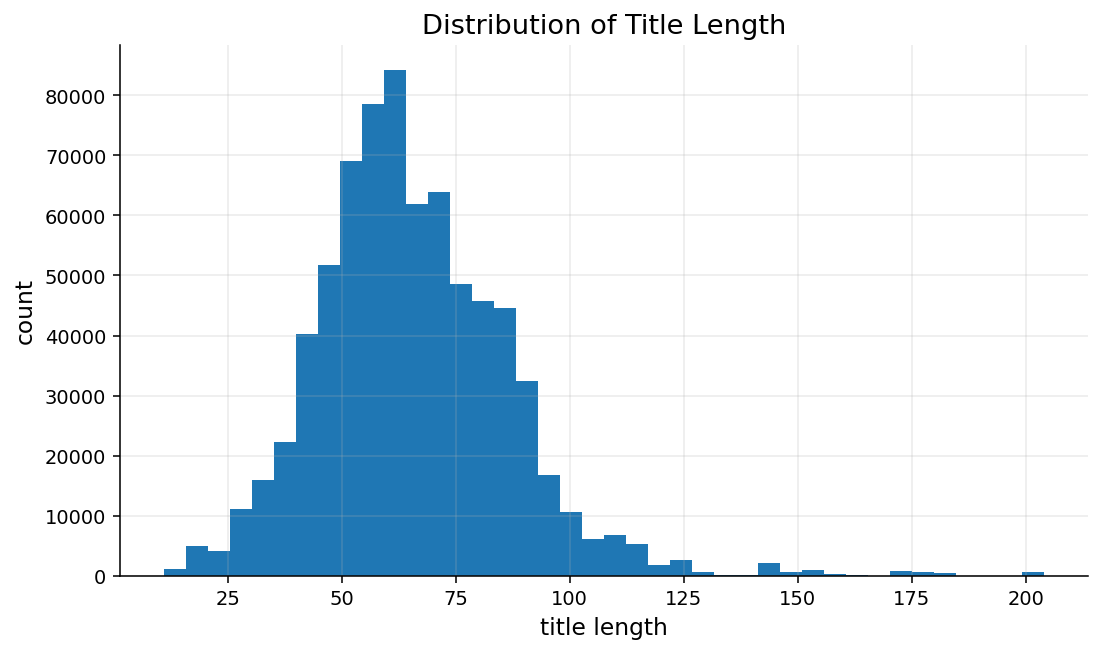

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(train_df["title_len"], bins=40)
ax.set_title("Distribution of Title Length")
ax.set_xlabel("title length")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

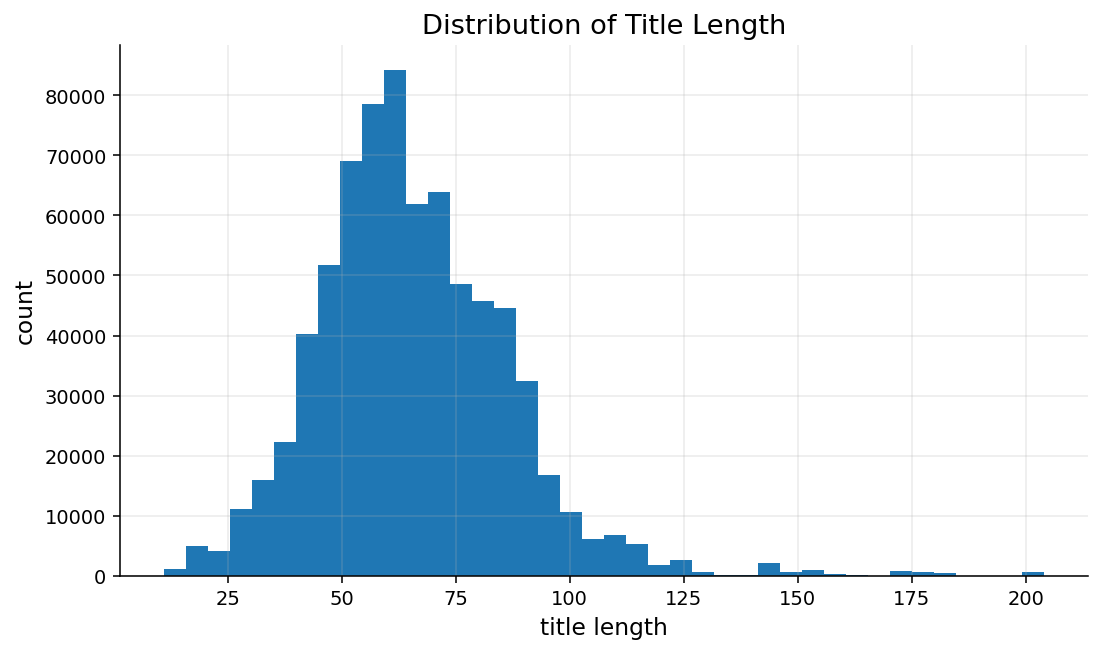

saved: ../results/figures/title_length_distribution.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(train_df["title_len"], bins=40)
ax.set_title("Distribution of Title Length")
ax.set_xlabel("title length")
ax.set_ylabel("count")
plt.tight_layout()

save_path = BASE_DIR / "results" / "figures" / "title_length_distribution.png"
plt.savefig(save_path, bbox_inches="tight")
plt.show()

print("saved:", save_path)

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss

做title的TF-IDF

In [15]:
tfidf_title = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=3
)

X_train_title = tfidf_title.fit_transform(train_df["title_text"])
X_valid_title = tfidf_title.transform(valid_df["title_text"])

print(X_train_title.shape)
print(X_valid_title.shape)

(737762, 5000)
(375609, 5000)


训练lr

In [16]:
lr_title = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_title.fit(X_train_title, y_train)

/Users/m5/Documents/GitHub/mind-thesis/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: divide by zero encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/m5/Documents/GitHub/mind-thesis/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: overflow encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)
/Users/m5/Documents/GitHub/mind-thesis/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:209: RuntimeWarning: invalid value encountered in matmul
  norm2_w = weights @ weights if weights.ndim == 1 else squared_norm(weights)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [17]:
valid_pred_title = lr_title.predict_proba(X_valid_title)[:, 1]
valid_pred_title[:10]

array([0.6885517 , 0.69267504, 0.48183936, 0.28466361, 0.36457071,
       0.60854841, 0.19017104, 0.50438656, 0.3051292 , 0.1714635 ])

In [18]:
auc_title = roc_auc_score(y_valid, valid_pred_title)
logloss_title = log_loss(y_valid, valid_pred_title)

print("TF-IDF(title)+LR AUC:", round(auc_title, 4))
print("TF-IDF(title)+LR LogLoss:", round(logloss_title, 4))

TF-IDF(title)+LR AUC: 0.5797
TF-IDF(title)+LR LogLoss: 0.6079


In [19]:
results_list = []

results_list.append({
    "model": "TFIDF_title_LR",
    "auc": auc_title,
    "logloss": logloss_title
})

pd.DataFrame(results_list)

,model,auc,logloss
0,TFIDF_title_LR,0.579711,0.607928


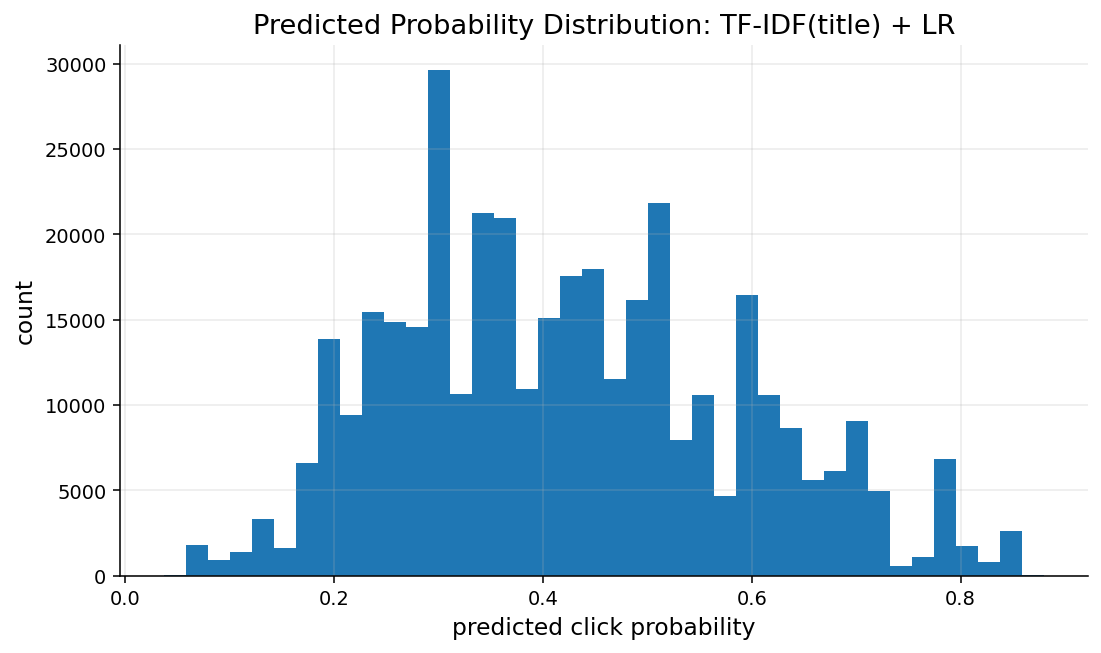

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(valid_pred_title, bins=40)
ax.set_title("Predicted Probability Distribution: TF-IDF(title) + LR")
ax.set_xlabel("predicted click probability")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()